# 1. SETUP

In [74]:
!pip install xgboost optuna scikit-learn pandas numpy matplotlib seaborn --quiet

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import optuna
import warnings
import gc
import pickle
from google.colab import files
from pandas.api.types import is_numeric_dtype
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [76]:
# Kiểm tra GPU để tăng tốc nội suy XGBoost
try:
    import torch
    if torch.cuda.is_available():
        print(f"Hệ thống đang sử dụng GPU: {torch.cuda.get_device_name(0)}")
        DEVICE = 'cuda'
        TREE_METHOD = 'hist'
    else:
        DEVICE = 'cpu'
        TREE_METHOD = 'hist'
except ImportError:
    DEVICE = 'cpu'
    TREE_METHOD = 'hist'

Hệ thống đang sử dụng GPU: Tesla T4


# 2. HÀM TỐI ƯU BỘ NHỚ

In [77]:
def reduce_mem_usage(df):
    """Ép kiểu dữ liệu (Downcasting) để tiết kiệm RAM, giới hạn tràn bộ nhớ khi load BDG2"""
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        if is_numeric_dtype(df[col]):
            c_min, c_max = df[col].min(), df[col].max()
            if pd.api.types.is_integer_dtype(df[col]):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Tối ưu RAM: {start_mem:.2f}MB -> {end_mem:.2f}MB')
    return df

# 3. DATA PIPELINE

In [78]:
def load_and_merge_data(max_buildings=50):
    url_elec = "https://media.githubusercontent.com/media/buds-lab/building-data-genome-project-2/master/data/meters/cleaned/electricity_cleaned.csv"
    url_weather = "https://media.githubusercontent.com/media/buds-lab/building-data-genome-project-2/master/data/weather/weather.csv"

    print("1. Đọc cấu trúc Điện năng...")
    header = pd.read_csv(url_elec, nrows=0)
    building_cols = header.columns[1:max_buildings+1].tolist()

    print(f"2. Tải Load Profile cho {len(building_cols)} tòa nhà...")
    df_elec = pd.read_csv(url_elec, usecols=['timestamp'] + building_cols, parse_dates=['timestamp'])
    df_elec = df_elec.set_index('timestamp').interpolate(method='linear', limit_direction='both').fillna(0)

    print("3. Tải Dữ liệu Thời tiết...")
    df_weather = pd.read_csv(url_weather, parse_dates=['timestamp'])

    processed_chunks = []
    target_weather_cols = ['airTemperature', 'dewTemperature', 'windSpeed', 'cloudCoverage', 'precipDepth1HR']

    print("4. Đồng bộ hóa Tín hiệu Thời tiết...")
    for col in building_cols:
        try:
            site_id = col.split('_')[0]

            # Khớp Site ID vào dữ liệu Thời tiết
            weather_site = df_weather[df_weather['site_id'] == site_id].copy()
            if weather_site.empty:
                print(f"  [!] Cảnh báo: Tòa nhà {col} không có dữ liệu thời tiết trạm '{site_id}'.")
                continue

            weather_site = weather_site.set_index('timestamp')

            # Chỉ Resample các biến định lượng (Numeric)
            available_weather = [c for c in target_weather_cols if c in weather_site.columns]
            weather_numeric = weather_site[available_weather].resample('H').mean()
            weather_numeric = weather_numeric.interpolate(method='linear', limit_direction='both').fillna(method='bfill').fillna(method='ffill')

            # Hợp nhất theo mốc thời gian (Index Join)
            temp_df = pd.DataFrame(df_elec[col]).rename(columns={col: 'load'})
            temp_df = temp_df.merge(weather_numeric, left_index=True, right_index=True, how='left')
            temp_df['building_name'] = col
            processed_chunks.append(temp_df.reset_index())

        except Exception as e:
            print(f"  [x] Bỏ qua {col} do lỗi Runtime: {str(e)}")
            continue

    if not processed_chunks:
        raise ValueError("Lỗi nghiêm trọng: Quá trình ánh xạ thất bại hoàn toàn. Không có DataFrame nào được tạo.")

    df_final = pd.concat(processed_chunks, axis=0, ignore_index=True)

    le = LabelEncoder()
    df_final['building_id'] = le.fit_transform(df_final['building_name'])
    df_final['log_load'] = np.log1p(df_final['load'])

    del df_elec, df_weather, processed_chunks
    gc.collect()

    return reduce_mem_usage(df_final), le

In [79]:
df_all, label_encoder = load_and_merge_data(max_buildings=100)

1. Đọc cấu trúc Điện năng...
2. Tải Load Profile cho 100 tòa nhà...
3. Tải Dữ liệu Thời tiết...
4. Đồng bộ hóa Tín hiệu Thời tiết...
Tối ưu RAM: 133.85MB -> 75.29MB


#4. TRÍCH XUẤT ĐẶC TRƯNG (FEATURE ENGINEERING)

In [84]:
def create_advanced_features(df):
    df = df.sort_values(['building_id', 'timestamp'])
    grouped = df.groupby('building_id')

    # Kỹ thuật: Phân rã Chu kỳ Thời gian (Cyclical Decomposition)
    df['hour'] = df.timestamp.dt.hour.astype(np.int8)
    df['dayofweek'] = df.timestamp.dt.dayofweek.astype(np.int8)
    df['month'] = df.timestamp.dt.month.astype(np.int8)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(np.int8)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24).astype(np.float32)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24).astype(np.float32)

    # Kỹ thuật: Mô hình Tự hồi quy chuỗi thời gian (Autoregressive Lags)
    for lag in [1, 2, 3, 4, 5, 6, 24, 48, 168]:
        df[f'load_lag_{lag}'] = grouped['log_load'].shift(lag).astype(np.float32)

    # Rolling Window Statistics (Đặc trưng thống kê trượt)
    # Ngắn hạn (3 giờ)
    df['roll_mean_3h'] = grouped['log_load'].transform(lambda x: x.rolling(3).mean()).astype(np.float32)
    df['roll_std_3h'] = grouped['log_load'].transform(lambda x: x.rolling(3).std()).astype(np.float32)
    # Trung hạn (24 giờ - Profile ngày)
    df['roll_mean_24h'] = grouped['log_load'].transform(lambda x: x.rolling(24).mean()).astype(np.float32)
    df['roll_max_24h'] = grouped['log_load'].transform(lambda x: x.rolling(24).max()).astype(np.float32)
    df['roll_min_24h'] = grouped['log_load'].transform(lambda x: x.rolling(24).min()).astype(np.float32)

    # Domain-Specific (Tỷ lệ tải - Load Factor Proxy)
    # Tránh chia cho 0 bằng cách cộng thêm epsilon 1e-5
    df['load_ratio_24h'] = (df['load_lag_1'] / (df['roll_mean_24h'] + 1e-5)).astype(np.float32)

    # Kỹ thuật: Nhiệt động lực học Trì hoãn (Thermal Lagging)
    if 'airTemperature' in df.columns:
        df['temp_lag_1'] = df.groupby('building_id')['airTemperature'].shift(1).astype(np.float32)
        df['temp_lag_2'] = df.groupby('building_id')['airTemperature'].shift(2).astype(np.float32)
        df['temp_lag_3'] = df.groupby('building_id')['airTemperature'].shift(3).astype(np.float32)
        df['temp_lag_4'] = df.groupby('building_id')['airTemperature'].shift(4).astype(np.float32)
        df['temp_lag_5'] = df.groupby('building_id')['airTemperature'].shift(5).astype(np.float32)
        df['temp_lag_6'] = df.groupby('building_id')['airTemperature'].shift(6).astype(np.float32)

        df['temp_roll_mean_6h'] = grouped['airTemperature'].transform(lambda x: x.rolling(6).mean()).astype(np.float32)
        df['temp_roll_std_6h'] = grouped['airTemperature'].transform(lambda x: x.rolling(6).std()).astype(np.float32)

    # 3. Temporal Dynamics (Động học: Tốc độ thay đổi)
    df['load_diff_1'] = grouped['log_load'].diff(1).astype(np.float32)
    df['load_diff_2'] = grouped['log_load'].diff(2).astype(np.float32)
    df['load_diff_3'] = grouped['log_load'].diff(3).astype(np.float32)
    df['load_diff_4'] = grouped['log_load'].diff(4).astype(np.float32)
    df['load_diff_5'] = grouped['log_load'].diff(5).astype(np.float32)
    df['load_diff_6'] = grouped['log_load'].diff(6).astype(np.float32)
    df['load_diff_24'] = grouped['log_load'].diff(24).astype(np.float32)

    # Kỹ thuật: Xác định Enthalpy xấp xỉ
    if 'dewTemperature' in df.columns and 'airTemperature' in df.columns:
        df['enthalpy'] = (1.006 * df['airTemperature'] + 0.622 * df['dewTemperature']).astype(np.float32)

    df = df.dropna()
    return reduce_mem_usage(df)

In [85]:
df_features = create_advanced_features(df_all)
del df_all; gc.collect()

Tối ưu RAM: 313.19MB -> 313.19MB


458

# 5. CHIA DỮ LIỆU HUẤN LUYỆN & KIỂM THỬ

In [86]:
split_date = df_features['timestamp'].quantile(0.8)
train_df = df_features[df_features['timestamp'] < split_date]
test_df = df_features[df_features['timestamp'] >= split_date]

In [87]:
features = [c for c in df_features.columns if c not in ['timestamp', 'load', 'log_load', 'building_name']]
X_train, y_train = train_df[features], train_df['log_load']
X_test, y_test = test_df[features], test_df['log_load']

In [88]:
print(f"{len(features)} Đặc trưng dự báo.")

43 Đặc trưng dự báo.


# 6. OPTUNA TUNING

In [90]:
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 400, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5.0),
        'tree_method': TREE_METHOD,
        'device': DEVICE,
        'objective': 'reg:squarederror'
    }

    # Sampling 15% dữ liệu để Tuning đảm bảo tốc độ
    sample_idx = np.random.choice(len(X_train), int(len(X_train)*0.1), replace=False)
    X_sample, y_sample = X_train.iloc[sample_idx], y_train.iloc[sample_idx]

    # Split Sub-validation
    val_size = int(len(X_sample) * 0.2)
    X_tr_s, y_tr_s = X_sample.iloc[:-val_size], y_sample.iloc[:-val_size]
    X_val_s, y_val_s = X_sample.iloc[-val_size:], y_sample.iloc[-val_size:]

    model = xgb.XGBRegressor(**param)

    # Fit với early stopping
    model.fit(
        X_tr_s, y_tr_s,
        eval_set=[(X_val_s, y_val_s)],
        verbose=False
    )

    preds = model.predict(X_val_s)
    return np.sqrt(mean_squared_error(y_val_s, preds))

In [91]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

In [92]:
best_params = study.best_params
best_params.update({
    'tree_method': TREE_METHOD,
    'device': DEVICE,
    'objective': 'reg:squarederror'
})
print(f"  -> Tham số tối ưu định tuyến: \n{best_params}")

  -> Tham số tối ưu định tuyến: 
{'n_estimators': 970, 'max_depth': 6, 'learning_rate': 0.04240179181603237, 'subsample': 0.6553531026911328, 'colsample_bytree': 0.82246318832479, 'reg_alpha': 0.45324055112901135, 'reg_lambda': 3.1129134284813924, 'tree_method': 'hist', 'device': 'cuda', 'objective': 'reg:squarederror'}


# 7. HUẤN LUYỆN MÔ HÌNH

In [93]:
final_model = xgb.XGBRegressor(**best_params)

In [94]:
final_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:1.30366	validation_1-rmse:1.25006
[100]	validation_0-rmse:0.02656	validation_1-rmse:0.02618
[200]	validation_0-rmse:0.01393	validation_1-rmse:0.01451
[300]	validation_0-rmse:0.01266	validation_1-rmse:0.01362
[400]	validation_0-rmse:0.01188	validation_1-rmse:0.01304
[500]	validation_0-rmse:0.01129	validation_1-rmse:0.01261
[600]	validation_0-rmse:0.01087	validation_1-rmse:0.01231
[700]	validation_0-rmse:0.01049	validation_1-rmse:0.01205
[800]	validation_0-rmse:0.01018	validation_1-rmse:0.01183
[900]	validation_0-rmse:0.00993	validation_1-rmse:0.01165
[969]	validation_0-rmse:0.00977	validation_1-rmse:0.01153


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.82246318832479, device='cuda',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.04240179181603237,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=970, n_jobs=None,
             num_parallel_tree=None, ...)

#8. EVALUATION METRICS

In [95]:
preds_real = np.expm1(final_model.predict(X_test))
y_test_real = np.expm1(y_test)

In [96]:
rmse = np.sqrt(mean_squared_error(y_test_real, preds_real))
mae = mean_absolute_error(y_test_real, preds_real)
r2 = r2_score(y_test_real, preds_real)

In [97]:
mask_nonzero = y_test_real > 0
mape = mean_absolute_percentage_error(y_test_real[mask_nonzero], preds_real[mask_nonzero])

In [98]:
print(f"  • RMSE (Độ lệch chuẩn) : {rmse:.4f} kWh")
print(f"  • MAE (Sai số tuyệt đối): {mae:.4f} kWh")
print(f"  • R² Score (Độ giải thích): {r2:.4f}")
print(f"  • MAPE (Sai số phần trăm) : {mape * 100:.2f}%")

  • RMSE (Độ lệch chuẩn) : 2.1235 kWh
  • MAE (Sai số tuyệt đối): 0.7826 kWh
  • R² Score (Độ giải thích): 0.9997
  • MAPE (Sai số phần trăm) : 0.82%


#9. VISUALIZATION

In [99]:
sample_bid = np.random.choice(test_df['building_id'].unique())
mask = test_df['building_id'] == sample_bid

In [100]:
b_name = label_encoder.inverse_transform([sample_bid])[0]

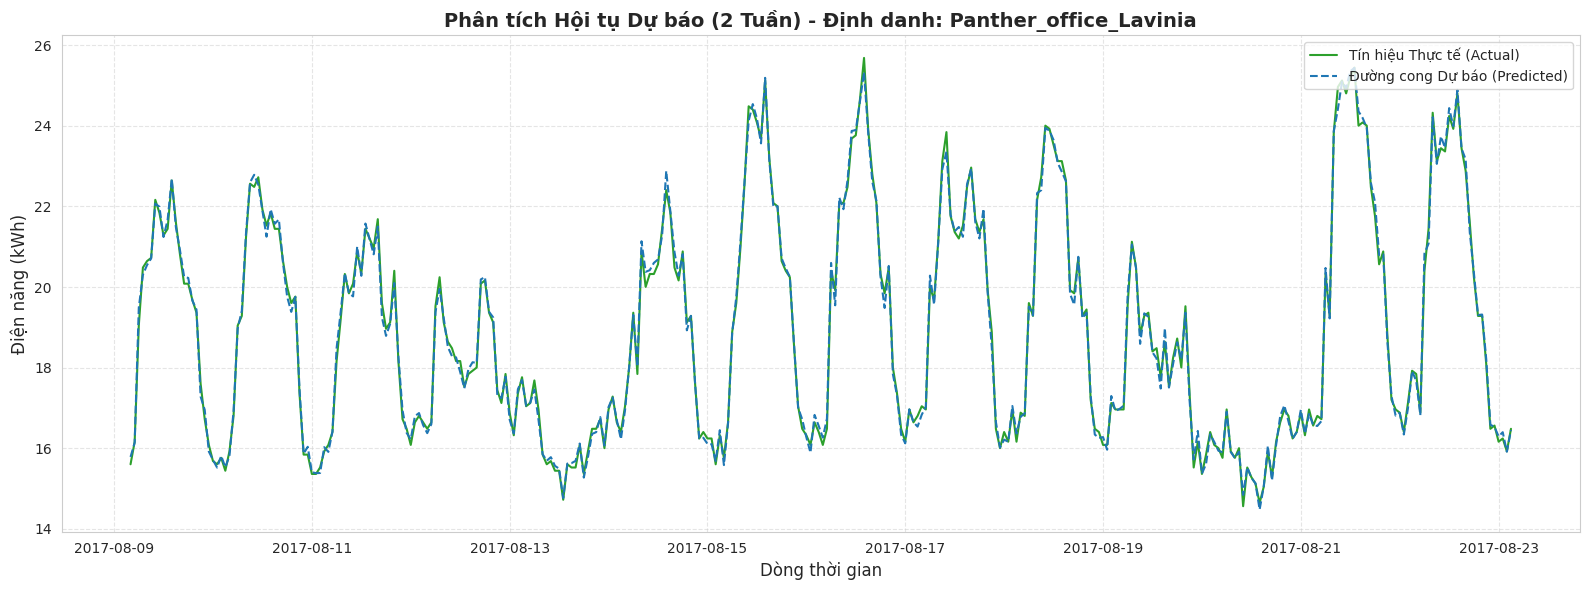

In [101]:
plt.figure(figsize=(16, 6))
plt.plot(test_df['timestamp'][mask].values[:336], y_test_real[mask].values[:336], label='Tín hiệu Thực tế (Actual)', color='#2ca02c')
plt.plot(test_df['timestamp'][mask].values[:336], preds_real[mask][:336], label='Đường cong Dự báo (Predicted)', color='#1f77b4', linestyle='--')
plt.title(f"Phân tích Hội tụ Dự báo (2 Tuần) - Định danh: {b_name}", fontsize=14, fontweight='bold')
plt.xlabel("Dòng thời gian", fontsize=12)
plt.ylabel("Điện năng (kWh)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#SAVE MODEL

In [102]:
model_filename = "xgboost_forecasting_optuna.json"
encoder_filename = "label_encoder_optuna.pkl"

final_model.save_model(model_filename)
with open(encoder_filename, 'wb') as f:
    pickle.dump(label_encoder, f)

print(f"\nĐã xuất File: {model_filename} & {encoder_filename}")
try:
    files.download(model_filename)
    files.download(encoder_filename)
except Exception:
    pass


Đã xuất File: xgboost_forecasting_optuna.json & label_encoder_optuna.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>